# YOLO Dataset Merger
Walks `data/processed/CafeV1/clips/<viewpoint>/<clip>/` (each holding `anns.json` in COCO format + an `images/` folder), merges every clip into a single YOLO-format dataset under `data/processed/CafeV1/yolo/`, and writes a matching `cafe_v1.yaml`.

Output layout:
```
data/processed/CafeV1/yolo/
├── cafe_v1.yaml
├── train/{images,labels}
└── val/{images,labels}
```

Split is **by clip**, not by frame, to avoid near-duplicate frame leakage between train and val.

## Imports

In [1]:
import sys
import json
import shutil
from pathlib import Path

In [2]:
# Set execution root in the project root
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

In [3]:
from src.utils.config.config import Config

## Config

In [4]:
config_loader = Config()
cfg = config_loader.load_config()

# Source anns
clips_root = cfg.project_root / config_loader.get("paths", "dataset.processed") / "CafeV1" / "clips"

# Source images
clips_imgs_root = cfg.project_root / config_loader.get("paths", "dataset.raw") / "CafeV1" / "yolo" / "clips"

# Destination
yolo_root = cfg.project_root / config_loader.get("paths", "dataset.processed") / "CafeV1" / "yolo" 

In [5]:
# COCO starts from id 1, while YOLO starts from 0, so shift down
COCO_TO_YOLO_CLASS = {
    1: 0, 
    2: 1,
    3: 2, 
    4: 3
  }

CLASS_NAMES = {
    0: "person", 
    1: "laptop", 
    2: "cell phone", 
    3: "book"
  }

# Number of clips per viewpoint to hold out for val (taken from the END of
# each viewpoint's sorted clip list). Clip names are not contiguous (e.g. 0,
# 1, 2, 19, 20, 21, 22, 450, 451), so we can't match on literal names —
# instead we count clips per viewpoint after sorting and hold out the last N.
VAL_CLIPS_PER_VP = 2

## Functions

### prepare_dirs

In [6]:
def prepare_dirs(yolo_root):
    for split in ("train", "val"):
        (yolo_root / split / "images").mkdir(parents=True, exist_ok=True)
        (yolo_root / split / "labels").mkdir(parents=True, exist_ok=True)

### coco_bbox_to_yolo_line
Convert a single COCO annotation to one YOLO label line.

In [7]:
def coco_bbox_to_yolo_line(ann, img_w, img_h):
    # COCO bbox is [x1, y1, w, h] in absolute pixels.
    
    # YOLO is normalized to [0, 1]
    # With a format of: class x_center y_center width height

    x1, y1, w, h = ann["bbox"]
    xc = (x1 + w / 2.0) / img_w
    yc = (y1 + h / 2.0) / img_h
    wn = w / img_w
    hn = h / img_h

    yolo_cls = COCO_TO_YOLO_CLASS[ann["category_id"]]
    return f"{yolo_cls} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}"

### process_clip

In [8]:
def process_clip(viewpoint_id, clip_id, clip_path, split, yolo_root):
    anns_path = clip_path / "anns.json"
    images_dir = clips_imgs_root / str(viewpoint_id) / str(clip_id) / "images" # Get the images from the raw directory

    print(images_dir)
    # Make sure anns and imgs exist
    if not anns_path.exists() or not images_dir.exists():
        print(f"Skipping vp{viewpoint_id} clip{clip_id}: missing anns.json or images/")
        return 0, 0

    # Load anns
    with open(anns_path, "r") as f:
        coco = json.load(f)

    # Group annotations by image_id for O(1) lookup
    anns_by_image = {}
    for ann in coco.get("annotations", []):
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    out_images_dir = yolo_root / split / "images"
    out_labels_dir = yolo_root / split / "labels"

    n_images = 0
    n_anns = 0
    
    # Loop through clip frames
    for img in coco.get("images", []):
        src_image = images_dir / img["file_name"]
        if not src_image.exists():
            print(f"Missing frame {src_image}")
            continue

        # Extract frame file info
        stem = Path(img["file_name"]).stem
        ext = Path(img["file_name"]).suffix

        # Name format for the frame and ann
        new_name = f"vp{viewpoint_id}_clip{clip_id}_{stem}"

        # Copy the frame to the images folder
        shutil.copy2(src_image, out_images_dir / f"{new_name}{ext}")

        # Convert COCO anns to YOLO format
        lines = [
            coco_bbox_to_yolo_line(a, img["width"], img["height"])
            for a in anns_by_image.get(img["id"], [])
        ]
        
        # Write an ann label .txt for the whole clip
        (out_labels_dir / f"{new_name}.txt").write_text("\n".join(lines))

        n_images += 1
        n_anns += len(lines)

    return n_images, n_anns

### write_dataset_yaml
Self-contained YAML — uses `path: .` so the dataset folder is relocatable.

In [10]:
def write_dataset_yaml(yolo_root):
    names_block = "\n".join(f"  {i}: {name}" for i, name in CLASS_NAMES.items())
    yaml_text = (
        "# Auto-generated by yolo_merger.ipynb.\n"
        f"path: {yolo_root.as_posix()}\n"
        "train: train/images\n"
        "val: val/images\n"
        f"nc: {len(CLASS_NAMES)}\n"
        "names:\n"
        f"{names_block}\n"
    )
    out_path = yolo_root / "cafe_v1.yaml"
    out_path.write_text(yaml_text)
    print(f"Wrote {out_path}")

## Run

In [11]:
def main():
    if not clips_root.exists():
        raise FileNotFoundError(f"clips_root does not exist: {clips_root}")

    prepare_dirs(yolo_root)

    viewpoint_dirs = sorted(
        [p for p in clips_root.iterdir() if p.is_dir()],
        key=lambda p: int(p.name),
    )

    totals = {"train": [0, 0], "val": [0, 0]}

    for vp_path in viewpoint_dirs:
        vp_id = int(vp_path.name)
        print(f"Viewpoint {vp_id}")

        clip_dirs = sorted(
            [p for p in vp_path.iterdir() if p.is_dir()],
            key=lambda p: int(p.name),
        )

        # Last VAL_CLIPS_PER_VP entries (after sorting) go to val.
        n_clips = len(clip_dirs)
        val_threshold = n_clips - VAL_CLIPS_PER_VP

        for clip_idx, clip_path in enumerate(clip_dirs):
            clip_id = int(clip_path.name)

            split = "val" if clip_idx >= val_threshold else "train"

            n_imgs, n_anns = process_clip(vp_id, clip_id, clip_path, split, yolo_root)

            totals[split][0] += n_imgs
            totals[split][1] += n_anns
            print(f"  vp{vp_id} clip{clip_id} (idx {clip_idx}) -> {split}: {n_imgs} images, {n_anns} annotations")

    write_dataset_yaml(yolo_root)

    print("\nDone.")
    for split, (n_imgs, n_anns) in totals.items():
        print(f"  {split}: {n_imgs} images, {n_anns} annotations")

In [12]:
main()

Viewpoint 1
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\0\images
  vp1 clip0 (idx 0) -> train: 30 images, 791 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\1\images
  vp1 clip1 (idx 1) -> train: 32 images, 816 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\2\images
  vp1 clip2 (idx 2) -> train: 32 images, 782 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\19\images
  vp1 clip19 (idx 3) -> train: 34 images, 855 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\20\images
  vp1 clip20 (idx 4) -> train: 19 images, 491 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\21\images
  vp1 clip21 (idx 5) -> train: 32 images, 882 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\22\images
  vp1 clip22 (idx 6) -> train: 32 images, 805 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\450\images
  vp1 clip450 (idx 7) -> val: 32 images, 800 annotations
C:\Research\Dataset\data\raw\CafeV1\yolo\clips\1\451\image

## Sanity check
Render one random image with its YOLO labels overlaid.

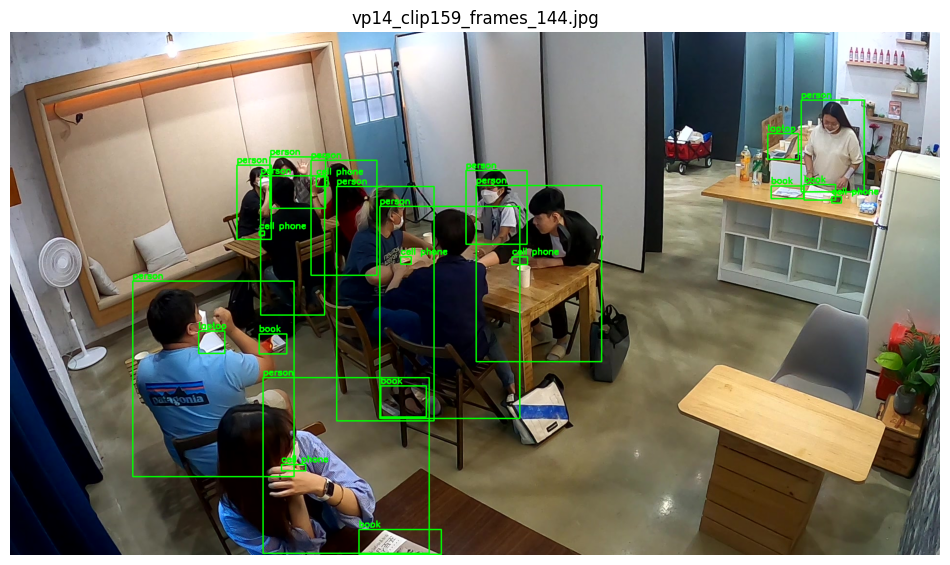

In [16]:
import random
import cv2
from matplotlib import pyplot as plt

split = "train"
imgs = list((yolo_root / split / "images").iterdir())
if not imgs:
    print("No images found — run the merge cell above first.")
else:
    img_path = random.choice(imgs)
    label_path = yolo_root / split / "labels" / f"{img_path.stem}.txt"

    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            cls, xc, yc, bw, bh = line.split()
            xc, yc, bw, bh = float(xc) * w, float(yc) * h, float(bw) * w, float(bh) * h
            x1, y1 = int(xc - bw / 2), int(yc - bh / 2)
            x2, y2 = int(xc + bw / 2), int(yc + bh / 2)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, CLASS_NAMES[int(cls)], (x1, max(y1 - 5, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()